In [20]:
!pip install openeo

In [21]:
!pip install rioxarray

In [22]:
!pip install geopandas

In [23]:
import openeo
import pandas as pd
import xarray as xr
import rioxarray as rxr
import rasterio
import geopandas as gpd
from shapely.geometry import shape

import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)



In [24]:
EP = "https://openeo.dataspace.copernicus.eu"
con = openeo.connect(EP).authenticate_oidc()
con


Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [25]:
cols = con.list_collections()
[s["id"] for s in cols if "SENTINEL" in s["id"].upper()]


['SENTINEL3_OLCI_L1B',
 'SENTINEL3_SLSTR',
 'SENTINEL_5P_L2',
 'SENTINEL2_L1C',
 'SENTINEL2_L2A',
 'SENTINEL1_GRD',
 'SENTINEL3_SYN_L2_SYN',
 'SENTINEL3_SLSTR_L2_LST',
 'SENTINEL1_GLOBAL_MOSAICS',
 'SENTINEL3_OLCI_L2_LAND',
 'SENTINEL3_OLCI_L2_WATER',
 'SENTINEL3_SYN_L2_AOD']

In [26]:

AOI = {
    "atitlan":   {"west": -91.326256, "east": -91.07151,  "south": 14.5948,  "north": 14.750979},
    "amatitlan": {"west": -90.638065, "east": -90.512924, "south": 14.412347,"north": 14.493799},
}

def aoi_bbox(name: str):
    a = AOI[name]
    return {"west": a["west"], "east": a["east"], "south": a["south"], "north": a["north"], "crs": "EPSG:4326"}

AOI


{'atitlan': {'west': -91.326256,
  'east': -91.07151,
  'south': 14.5948,
  'north': 14.750979},
 'amatitlan': {'west': -90.638065,
  'east': -90.512924,
  'south': 14.412347,
  'north': 14.493799}}

In [27]:
from datetime import date, timedelta

def month_range(start: date, end: date):
    """Genera [(start_i, end_i_exclusive), ...] mes a mes, inclusive del inicio, exclusivo del final."""
    cur = date(start.year, start.month, 1)
    out = []
    while cur < end:
        if cur.month == 12:
            nxt = date(cur.year + 1, 1, 1)
        else:
            nxt = date(cur.year, cur.month + 1, 1)
        out.append((cur, nxt))
        cur = nxt
    return out

def ensure_dir(p: str):
    import os
    os.makedirs(p, exist_ok=True)


In [28]:
# Colección S2 nivel L2A (refleja en superficie) para poder enmascarar por SCL (clasificación de escena)
S2_ID = "SENTINEL2_L2A"

# Rango 6 meses
DATE_START = date(2025, 1, 1)
DATE_END   = date(2025, 8, 1)


OUTDIR = "data_tif"
ensure_dir(OUTDIR)


In [29]:
from pathlib import Path
from openeo.processes import neq, and_

def download_month(con, lake_name: str, t0: date, t1: date):
    bbox = aoi_bbox(lake_name)

    cube = con.load_collection(
        S2_ID,
        spatial_extent=bbox,
        temporal_extent=[t0.isoformat(), t1.isoformat()],
        bands=["B04", "B05", "SCL"],
    )

    scl = cube.band("SCL")
    clear_mask = scl.apply(
        lambda x: and_(
            neq(x, 3),
            and_(
                neq(x, 8),
                and_(
                    neq(x, 9),
                    and_(neq(x, 10), neq(x, 11))
                )
            )
        )
    )

    cube = cube.mask(clear_mask).filter_bands(["B04", "B05"])
    cube = cube.aggregate_temporal_period(reducer="median", period="month")


    out = Path(OUTDIR) / f"{lake_name}_{t0.year:04d}-{t0.month:02d}.tif"
    cube.download(str(out), format="GTiff")
    return out



In [30]:
test_out = download_month(con, "atitlan", date(2025, 1, 1), date(2025, 2, 1))
test_out


PosixPath('data_tif/atitlan_2025-01.tif')

In [31]:
import rasterio, numpy as np

with rasterio.open(test_out) as ds:
    print("path:", ds.name)
    print("bands:", ds.count)
    print("crs:", ds.crs)
    print("shape (h,w):", ds.height, ds.width)
    b04 = ds.read(1, masked=True)
    b05 = ds.read(2, masked=True)
    print("B04 median:", float(np.nanmedian(b04)))
    print("B05 median:", float(np.nanmedian(b05)))


path: data_tif/atitlan_2025-01.tif
bands: 2
crs: EPSG:32615
shape (h,w): 1751 2759
B04 median: 1902.0
B05 median: 2303.0


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [32]:
months = month_range(DATE_START, DATE_END)
generated = []
for lake in ["atitlan", "amatitlan"]:
    for (t0, t1) in months:
        print(f"→ {lake} {t0:%Y-%m}")
        out = download_month(con, lake, t0, t1)
        generated.append(str(out))
print("Listo:", len(generated), "archivos")


→ atitlan 2025-01
→ atitlan 2025-02
→ atitlan 2025-03
→ atitlan 2025-04
→ atitlan 2025-05
→ atitlan 2025-06
→ atitlan 2025-07
→ amatitlan 2025-01
→ amatitlan 2025-02
→ amatitlan 2025-03
→ amatitlan 2025-04
→ amatitlan 2025-05
→ amatitlan 2025-06
→ amatitlan 2025-07
Listo: 14 archivos


# Calcular NDCI y exportar serie mensual

In [33]:
import re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import rasterio

IN_DIR = Path("data_tif")
OUT_CSV = Path("ndci_monthly.csv")

def compute_stats_ndci(tif_path: str):
    # Parseo (atitlan_2025-01.tif -> lake, YYYY-MM)
    name = Path(tif_path).stem
    m = re.match(r"^(?P<lake>[a-z]+)_(?P<ym>\d{4}-\d{2})$", name)
    assert m, f"Nombre inesperado: {name}"
    lake = m.group("lake")
    ym = m.group("ym")

    with rasterio.open(tif_path) as ds:
        b04 = ds.read(1, masked=True).astype("float64")
        b05 = ds.read(2, masked=True).astype("float64")

        # NDCI = (B05 - B04) / (B05 + B04)
        with np.errstate(divide="ignore", invalid="ignore"):
            ndci = (b05 - b04) / (b05 + b04)

        # Se convierte a ndarray con NaNs en los enmascarados
        arr = np.ma.masked_invalid(ndci).filled(np.nan)

        # info estadistica ignorando NaNs
        mean   = float(np.nanmean(arr))
        median = float(np.nanmedian(arr))
        p25    = float(np.nanpercentile(arr, 25))
        p75    = float(np.nanpercentile(arr, 75))

    return {"date": f"{ym}-01", "lake": lake, "ndci_mean": mean,
            "ndci_median": median, "ndci_p25": p25, "ndci_p75": p75}


rows = []
for tif in sorted(glob(str(IN_DIR / "*.tif"))):
    rows.append(compute_stats_ndci(tif))

df = pd.DataFrame(rows).sort_values(["lake", "date"]).reset_index(drop=True)
df.to_csv(OUT_CSV, index=False)
df.head(10)


,date,lake,ndci_mean,ndci_median,ndci_p25,ndci_p75
0,2025-01-01,amatitlan,0.052929,0.041513,0.031091,0.062623
1,2025-02-01,amatitlan,0.063786,0.039271,0.026775,0.067727
2,2025-03-01,amatitlan,0.095738,0.074614,0.034789,0.138834
3,2025-04-01,amatitlan,0.076351,0.047514,0.027575,0.092265
4,2025-05-01,amatitlan,0.061414,0.053284,0.029515,0.089628
5,2025-06-01,amatitlan,0.084888,0.084151,0.056360,0.112483
6,2025-07-01,amatitlan,0.077617,0.053735,0.026112,0.104887
7,2025-01-01,atitlan,0.100107,0.072856,0.054865,0.106100
8,2025-02-01,atitlan,0.060363,0.047201,0.031859,0.065489
9,2025-03-01,atitlan,0.060047,0.040979,0.023441,0.073726


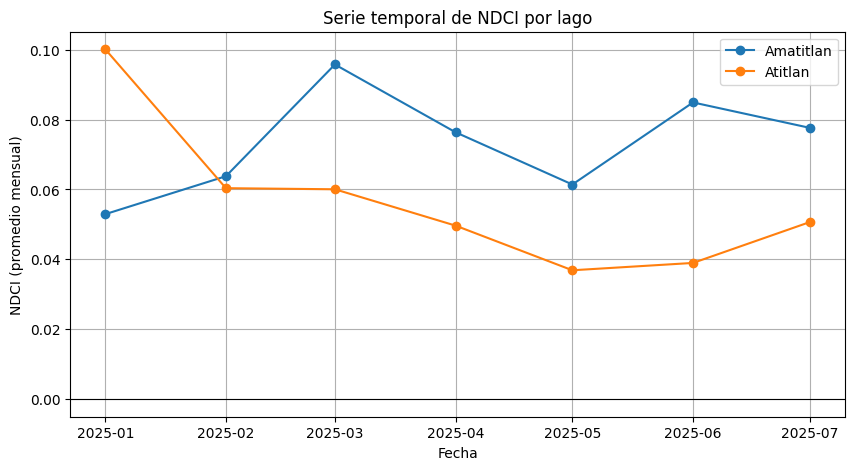

In [34]:

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10,5))
for lake in df["lake"].unique():
    subset = df[df["lake"] == lake]
    plt.plot(subset["date"], subset["ndci_mean"], marker="o", label=lake.capitalize())

plt.title("Serie temporal de NDCI por lago")
plt.xlabel("Fecha")
plt.ylabel("NDCI (promedio mensual)")
plt.axhline(0, color="black", lw=0.8)
plt.legend()
plt.grid(True)
plt.show()


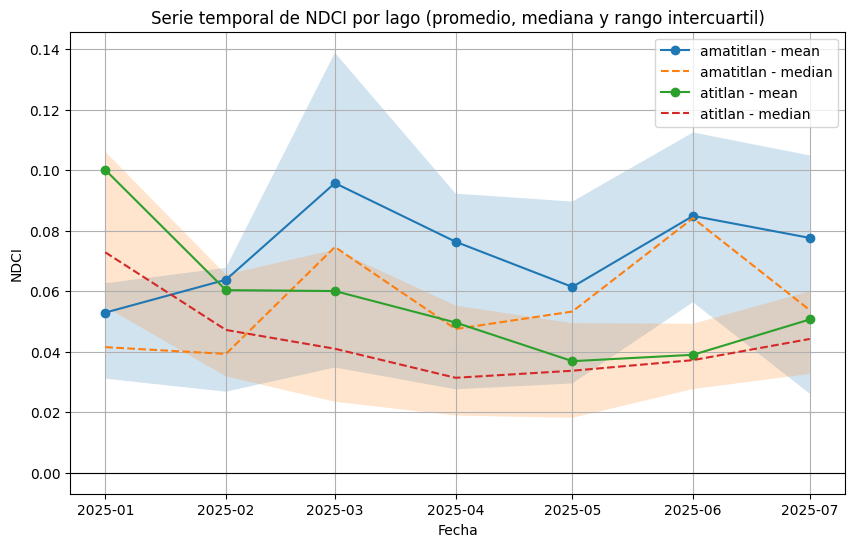

In [35]:
plt.figure(figsize=(10,6))

for lake in df["lake"].unique():
    subset = df[df["lake"] == lake]

    # promedio mensual
    plt.plot(subset["date"], subset["ndci_mean"], marker="o", label=f"{lake} - mean")

    # mediana mensual
    plt.plot(subset["date"], subset["ndci_median"], linestyle="--", label=f"{lake} - median")

    # percentiles
    plt.fill_between(
        subset["date"],
        subset["ndci_p25"],
        subset["ndci_p75"],
        alpha=0.2
    )

plt.title("Serie temporal de NDCI por lago (promedio, mediana y rango intercuartil)")
plt.xlabel("Fecha")
plt.ylabel("NDCI")
plt.axhline(0, color="black", lw=0.8)
plt.legend()
plt.grid(True)
plt.show()


En la primera figura, que presenta el promedio mensual, se observa que Amatitlán presenta valores de NDCI más altos en la mayoría de los meses, con picos notables en marzo y junio, lo que sugiere mayores concentraciones de clorofila o floraciones algales en esos periodos, Atitlán, en cambio, mantiene valores más bajos y relativamente estables, aunque inicia el año con un valor elevado en enero que luego disminuye progresivamente. En la segunda figura, se aprecia que en ambos lagos existe cierta variabilidad mensual, pero en Amatitlán las diferencias entre media y mediana son más pronunciadas, lo que indica la presencia de valores atípicos o distribución sesgada. El rango intercuartil también es más amplio en Amatitlán, reflejando mayor variabilidad en los datos, mientras que en Atitlán las fluctuaciones son menores y más consistentes a lo largo del tiempo.

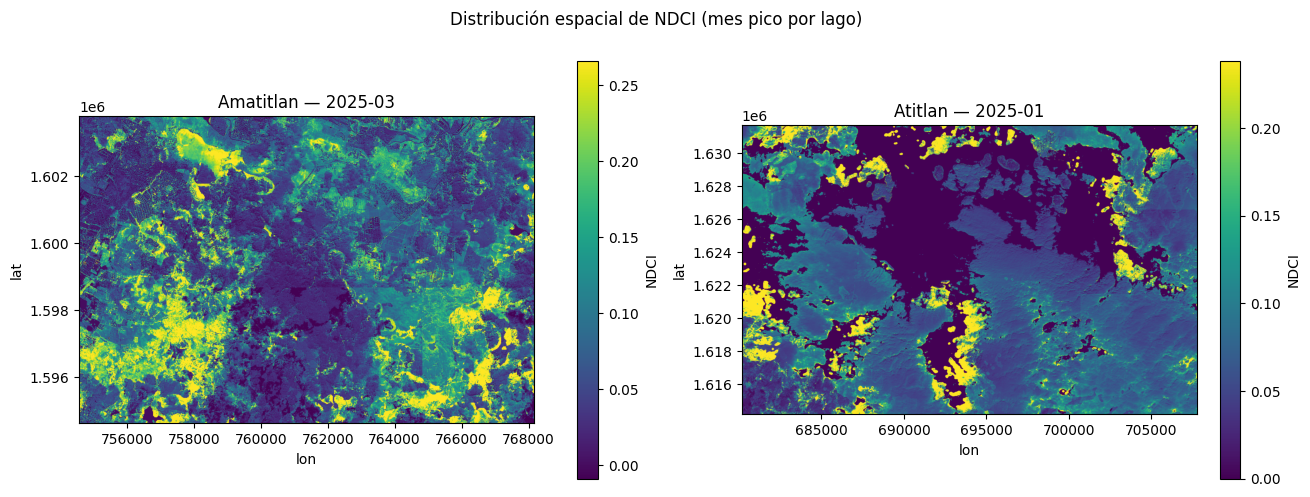

In [36]:


# Se toma el mes pico por lago
df_peak = df.loc[df.groupby("lake")["ndci_mean"].idxmax()].copy()
df_peak

def ndci_from_tif(tif_path: str):
    with rasterio.open(tif_path) as ds:
        b04 = ds.read(1).astype("float64")
        b05 = ds.read(2).astype("float64")
        with np.errstate(divide="ignore", invalid="ignore"):
            ndci = (b05 - b04) / (b05 + b04)
        ndci = np.where(np.isfinite(ndci), ndci, np.nan)
        bounds = ds.bounds
        extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    return ndci, extent

fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

for ax, (_, row) in zip(axes, df_peak.iterrows()):
    ym = row["date"].strftime("%Y-%m")
    tif = Path("data_tif") / f"{row['lake']}_{ym}.tif"
    ndci, extent = ndci_from_tif(str(tif))

    vmin, vmax = np.nanpercentile(ndci, [5, 95])
    im = ax.imshow(ndci, extent=extent, origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(f"{row['lake'].capitalize()} — {ym}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("NDCI")

plt.suptitle("Distribución espacial de NDCI (mes pico por lago)", y=1.02)
plt.show()



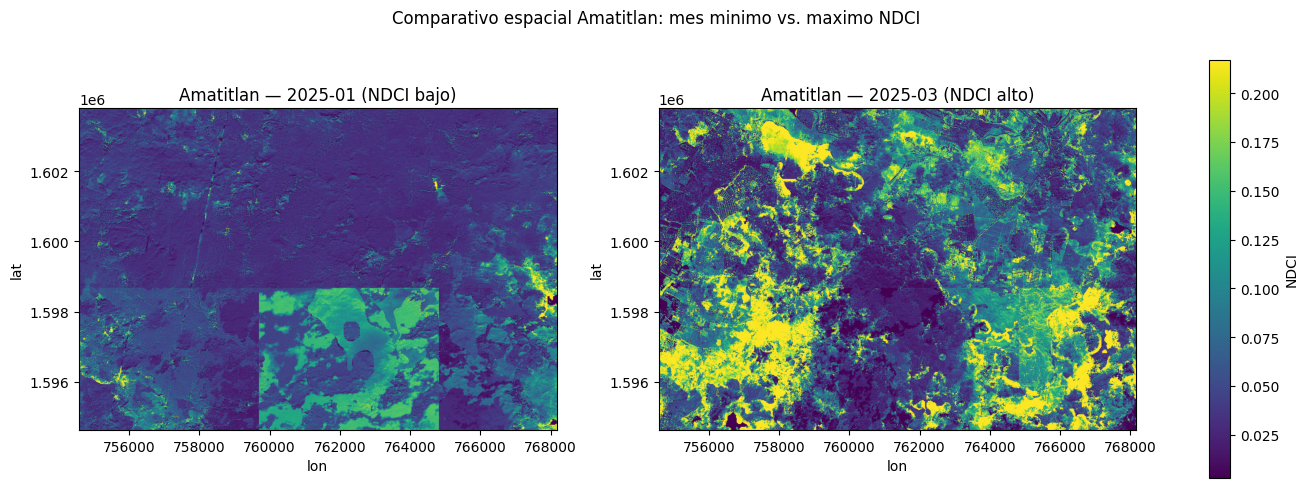

In [37]:


def ndci_from_tif(tif_path: str):
    with rasterio.open(tif_path) as ds:
        b04 = ds.read(1).astype("float64")
        b05 = ds.read(2).astype("float64")
        with np.errstate(divide="ignore", invalid="ignore"):
            ndci = (b05 - b04) / (b05 + b04)
        ndci = np.where(np.isfinite(ndci), ndci, np.nan)
        bounds = ds.bounds
        extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    return ndci, extent

# elegir fechas min/max por NDCI (Amatitlan)
lake = "amatitlan"
sub = df[df["lake"] == lake].copy()
d_min = sub.loc[sub["ndci_mean"].idxmin(), "date"]
d_max = sub.loc[sub["ndci_mean"].idxmax(), "date"]
ym_min = d_min.strftime("%Y-%m")
ym_max = d_max.strftime("%Y-%m")

tif_min = Path("data_tif") / f"{lake}_{ym_min}.tif"
tif_max = Path("data_tif") / f"{lake}_{ym_max}.tif"

ndci_min, ext_min = ndci_from_tif(str(tif_min))
ndci_max, ext_max = ndci_from_tif(str(tif_max))


stack = np.concatenate([ndci_min[np.isfinite(ndci_min)], ndci_max[np.isfinite(ndci_max)]])
vmin, vmax = np.nanpercentile(stack, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

im0 = axes[0].imshow(ndci_min, extent=ext_min, origin="upper", vmin=vmin, vmax=vmax)
axes[0].set_title(f"{lake.capitalize()} — {ym_min} (NDCI bajo)")
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")

im1 = axes[1].imshow(ndci_max, extent=ext_max, origin="upper", vmin=vmin, vmax=vmax)
axes[1].set_title(f"{lake.capitalize()} — {ym_max} (NDCI alto)")
axes[1].set_xlabel("lon"); axes[1].set_ylabel("lat")

cbar = plt.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("NDCI")
plt.suptitle("Comparativo espacial Amatitlan: mes minimo vs. maximo NDCI", y=1.02)
plt.show()


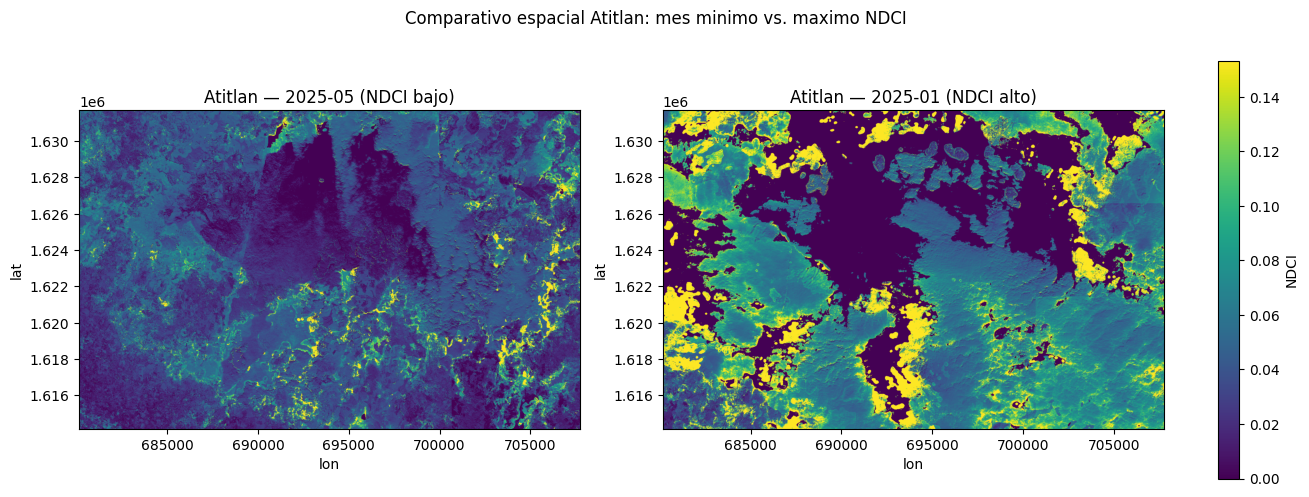

In [38]:
lake = "atitlan"
sub = df[df["lake"] == lake].copy()
d_min = sub.loc[sub["ndci_mean"].idxmin(), "date"]
d_max = sub.loc[sub["ndci_mean"].idxmax(), "date"]
ym_min = d_min.strftime("%Y-%m")
ym_max = d_max.strftime("%Y-%m")

tif_min = Path("data_tif") / f"{lake}_{ym_min}.tif"
tif_max = Path("data_tif") / f"{lake}_{ym_max}.tif"

ndci_min, ext_min = ndci_from_tif(str(tif_min))
ndci_max, ext_max = ndci_from_tif(str(tif_max))

stack = np.concatenate([ndci_min[np.isfinite(ndci_min)], ndci_max[np.isfinite(ndci_max)]])
vmin, vmax = np.nanpercentile(stack, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

im0 = axes[0].imshow(ndci_min, extent=ext_min, origin="upper", vmin=vmin, vmax=vmax)
axes[0].set_title(f"{lake.capitalize()} — {ym_min} (NDCI bajo)")
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")

im1 = axes[1].imshow(ndci_max, extent=ext_max, origin="upper", vmin=vmin, vmax=vmax)
axes[1].set_title(f"{lake.capitalize()} — {ym_max} (NDCI alto)")
axes[1].set_xlabel("lon"); axes[1].set_ylabel("lat")

cbar = plt.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("NDCI")
plt.suptitle("Comparativo espacial Atitlan: mes minimo vs. maximo NDCI", y=1.02)
plt.show()


Las gráficas espaciales revelan un patron claro de variabilidad estacional del índice NDCI en ambos lagos.

En amatitlan, el mes con valores minimos (enero 2025) presenta un NDCI muy bajo en casi toda la superficie, mientras que en el mes pico (marzo 2025) se observa un incremento generalizado, con amplias zonas en valores altos, lo que sugiere una proliferación de algas o material fitoplanctonico.

En atitlan, el mes de menor valor (mayo 2025) muestra niveles bajos y homogeneos, mientras que en el mes de mayor valor (enero 2025) se aprecian areas definidas con concentraciones elevadas de NDCI, particularmente cerca de ciertas orillas.

In [39]:

OUTDIR_VEG = Path("data_tif_veg"); OUTDIR_VEG.mkdir(exist_ok=True)

def download_month_veg(con, lake_name: str, t0: date, t1: date):
    bbox = aoi_bbox(lake_name)
    cube = con.load_collection(
        S2_ID,
        spatial_extent=bbox,
        temporal_extent=[t0.isoformat(), t1.isoformat()],
        bands=["B03","B04","B08","SCL"],
    )

    scl = cube.band("SCL")
    clear_mask = scl.apply(
        lambda x: and_(
            neq(x, 3),
            and_(neq(x, 8), and_(neq(x, 9), and_(neq(x, 10), neq(x, 11))))
        )
    )
    cube = cube.mask(clear_mask).filter_bands(["B03","B04","B08"])
    cube = cube.aggregate_temporal_period(reducer="median", period="month")

    out = OUTDIR_VEG / f"{lake_name}_{t0.year:04d}-{t0.month:02d}.tif"
    cube.download(str(out), format="GTiff")
    return out


In [40]:
test_veg = download_month_veg(con, "atitlan", date(2025,1,1), date(2025,2,1))
test_veg


PosixPath('data_tif_veg/atitlan_2025-01.tif')

In [41]:
months = month_range(DATE_START, DATE_END)
generated_veg = []
for lake in ["atitlan", "amatitlan"]:
    for (t0, t1) in months:
        print(f"→ {lake} {t0:%Y-%m}")
        generated_veg.append(str(download_month_veg(con, lake, t0, t1)))
len(generated_veg)


→ atitlan 2025-01
→ atitlan 2025-02
→ atitlan 2025-03
→ atitlan 2025-04
→ atitlan 2025-05
→ atitlan 2025-06
→ atitlan 2025-07
→ amatitlan 2025-01
→ amatitlan 2025-02
→ amatitlan 2025-03
→ amatitlan 2025-04
→ amatitlan 2025-05
→ amatitlan 2025-06
→ amatitlan 2025-07


14

In [42]:


def stats_ndvi_ndwi(tif_path: str):
    name = Path(tif_path).stem
    m = re.match(r"^(?P<lake>[a-z]+)_(?P<ym>\d{4}-\d{2})$", name)
    lake, ym = m.group("lake"), m.group("ym")
    with rasterio.open(tif_path) as ds:
        b03 = ds.read(1).astype("float64")
        b04 = ds.read(2).astype("float64")
        b08 = ds.read(3).astype("float64")
        with np.errstate(divide="ignore", invalid="ignore"):
            ndvi = (b08 - b04) / (b08 + b04)
            ndwi = (b03 - b08) / (b03 + b08)
        ndvi = np.where(np.isfinite(ndvi), ndvi, np.nan)
        ndwi = np.where(np.isfinite(ndwi), ndwi, np.nan)
    def q(arr, p): return float(np.nanpercentile(arr, p))
    row = dict(
        date=f"{ym}-01", lake=lake,
        ndvi_mean=float(np.nanmean(ndvi)), ndvi_median=float(np.nanmedian(ndvi)),
        ndvi_p25=q(ndvi,25), ndvi_p75=q(ndvi,75),
        ndwi_mean=float(np.nanmean(ndwi)), ndwi_median=float(np.nanmedian(ndwi)),
        ndwi_p25=q(ndwi,25), ndwi_p75=q(ndwi,75),
    )
    return row

rows = [stats_ndvi_ndwi(p) for p in sorted(glob(str(OUTDIR_VEG / "*.tif")))]
df_veg = pd.DataFrame(rows).sort_values(["lake","date"]).reset_index(drop=True)
df_veg.to_csv("ndvi_ndwi_monthly.csv", index=False)
df_veg.head(10)


,date,lake,ndvi_mean,ndvi_median,ndvi_p25,ndvi_p75,ndwi_mean,ndwi_median,ndwi_p25,ndwi_p75
0,2025-01-01,amatitlan,0.043104,0.024064,-0.001823,0.063378,-0.025747,-0.014666,-0.045865,0.014671
1,2025-02-01,amatitlan,0.098695,0.026105,-0.000000,0.118634,-0.080414,-0.011895,-0.109027,0.016471
2,2025-03-01,amatitlan,0.204979,0.154111,0.052125,0.325321,-0.179177,-0.146655,-0.320312,-0.021438
3,2025-04-01,amatitlan,0.107343,0.035768,-0.000000,0.148503,-0.090995,-0.022348,-0.137692,0.000000
4,2025-05-01,amatitlan,0.120530,0.097258,0.034649,0.187339,-0.076516,-0.060637,-0.144886,0.007752
5,2025-06-01,amatitlan,0.202864,0.196789,0.118886,0.287419,-0.160873,-0.158551,-0.240040,-0.082769
6,2025-07-01,amatitlan,0.156101,0.096594,0.021813,0.240467,-0.123193,-0.075722,-0.207224,-0.001352
7,2025-01-01,atitlan,0.124722,0.064748,0.000000,0.179882,-0.112082,-0.054242,-0.171967,0.000000
8,2025-02-01,atitlan,0.092082,0.044776,0.012600,0.116214,-0.069960,-0.025490,-0.093459,0.001918
9,2025-03-01,atitlan,0.097280,0.029001,0.000000,0.142129,-0.075715,-0.007652,-0.118782,0.000000


In [43]:

df["date"] = pd.to_datetime(df["date"])
df_veg["date"] = pd.to_datetime(df_veg["date"])

df_all = pd.merge(df, df_veg, on=["lake","date"], how="inner")

# Correlacion global (todos los meses y lagos)
corr_global = df_all[["ndci_mean","ndvi_mean","ndwi_mean"]].corr()

# Correlacion por lago
corr_by_lake = {}
for lake in df_all["lake"].unique():
    sub = df_all[df_all["lake"] == lake]
    corr_by_lake[lake] = sub[["ndci_mean","ndvi_mean","ndwi_mean"]].corr()

corr_global, corr_by_lake


(           ndci_mean  ndvi_mean  ndwi_mean
 ndci_mean   1.000000   0.826842  -0.900309
 ndvi_mean   0.826842   1.000000  -0.980761
 ndwi_mean  -0.900309  -0.980761   1.000000,
 {'amatitlan':            ndci_mean  ndvi_mean  ndwi_mean
  ndci_mean   1.000000   0.912453  -0.964362
  ndvi_mean   0.912453   1.000000  -0.983127
  ndwi_mean  -0.964362  -0.983127   1.000000,
  'atitlan':            ndci_mean  ndvi_mean  ndwi_mean
  ndci_mean   1.000000   0.854951  -0.917351
  ndvi_mean   0.854951   1.000000  -0.976142
  ndwi_mean  -0.917351  -0.976142   1.000000})

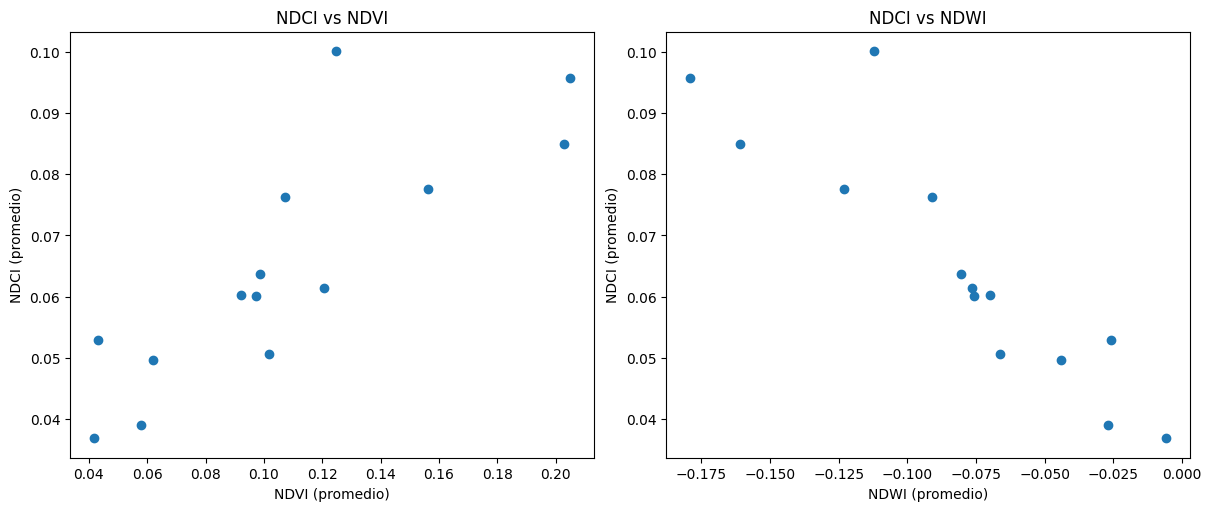

In [44]:

fig, axes = plt.subplots(1,2, figsize=(12,5), constrained_layout=True)
axes[0].scatter(df_all["ndvi_mean"], df_all["ndci_mean"])
axes[0].set_xlabel("NDVI (promedio)"); axes[0].set_ylabel("NDCI (promedio)"); axes[0].set_title("NDCI vs NDVI")

axes[1].scatter(df_all["ndwi_mean"], df_all["ndci_mean"])
axes[1].set_xlabel("NDWI (promedio)"); axes[1].set_ylabel("NDCI (promedio)"); axes[1].set_title("NDCI vs NDWI")

plt.show()


El analisis de correlación muestra que el indice de concentración de cianobacterias presenta una correlación positiva alta con el NDVI, lo que puede indicar que a mayor cobertura vegetal suele haber una mayor presencia de cianobacterias. Por otro lado, el NDCI tiene una correlación negativa muy fuerte con el NDWI, lo que sugiere que un mayor contenido de agua libre sin vegetación se asocia con menor concentración de cianobacterias. Esto es consistente con el hecho de que las cianobacterias proliferan en aguas mas eutrofizadas y con menor circulación, donde la vegetación flotante y el fitoplancton aumentan y, por tanto, el NDVI sube mientras el NDWI baja.

In [45]:
from scipy.stats import linregress
import pymannkendall as mk

df_all = df_all.copy()
df_all["date"] = pd.to_datetime(df_all["date"])

def month_index(dates: pd.Series) -> pd.Series:
    m = dates.dt.year * 12 + dates.dt.month
    return m - m.min()

indices = ["ndci_mean", "ndvi_mean", "ndwi_mean"]
rows = []

for lake in df_all["lake"].unique():
    sub = df_all[df_all["lake"] == lake].sort_values("date")
    t = month_index(sub["date"]).astype(float).values
    for idx in indices:
        y = sub[idx].values


        lr = linregress(t, y)
        slope_year = lr.slope * 12

        # (Mann–Kendall)
        mkres = mk.original_test(y)

        rows.append({
            "lake": lake,
            "index": idx.replace("_mean","").upper(),
            "n": len(sub),
            "lin_slope_per_month": lr.slope,
            "lin_slope_per_year": slope_year,
            "lin_r": lr.rvalue,
            "lin_pvalue": lr.pvalue,
            "mk_trend": mkres.trend,
            "mk_tau": mkres.Tau,
            "mk_slope_per_month": mkres.slope,
            "mk_pvalue": mkres.p,
        })

trend_tbl = pd.DataFrame(rows)
trend_tbl


,lake,index,n,lin_slope_per_month,lin_slope_per_year,lin_r,lin_pvalue,mk_trend,mk_tau,mk_slope_per_month,mk_pvalue
0,amatitlan,NDCI,7,0.002927,0.035119,0.427460,0.338761,no trend,0.333333,0.004115,0.367521
1,amatitlan,NDVI,7,0.016531,0.198378,0.608495,0.147081,no trend,0.523810,0.017785,0.133128
2,amatitlan,NDWI,7,-0.012521,-0.150256,-0.510459,0.241759,no trend,-0.333333,-0.012692,0.367521
3,atitlan,NDCI,7,-0.007652,-0.091824,-0.778998,0.038993,no trend,-0.619048,-0.007022,0.071505
4,atitlan,NDVI,7,-0.006880,-0.082565,-0.507487,0.244976,no trend,-0.333333,-0.013102,0.367521
5,atitlan,NDWI,7,0.010481,0.125776,0.647101,0.116177,no trend,0.523810,0.012982,0.133128


In [46]:
trend_tbl = trend_tbl.sort_values(["lake","index"]).reset_index(drop=True)
trend_tbl["lin_sig_0.05"] = trend_tbl["lin_pvalue"] < 0.05
trend_tbl["mk_sig_0.05"]  = trend_tbl["mk_pvalue"]  < 0.05
trend_tbl


,lake,index,n,lin_slope_per_month,lin_slope_per_year,lin_r,lin_pvalue,mk_trend,mk_tau,mk_slope_per_month,mk_pvalue,lin_sig_0.05,mk_sig_0.05
0,amatitlan,NDCI,7,0.002927,0.035119,0.427460,0.338761,no trend,0.333333,0.004115,0.367521,False,False
1,amatitlan,NDVI,7,0.016531,0.198378,0.608495,0.147081,no trend,0.523810,0.017785,0.133128,False,False
2,amatitlan,NDWI,7,-0.012521,-0.150256,-0.510459,0.241759,no trend,-0.333333,-0.012692,0.367521,False,False
3,atitlan,NDCI,7,-0.007652,-0.091824,-0.778998,0.038993,no trend,-0.619048,-0.007022,0.071505,True,False
4,atitlan,NDVI,7,-0.006880,-0.082565,-0.507487,0.244976,no trend,-0.333333,-0.013102,0.367521,False,False
5,atitlan,NDWI,7,0.010481,0.125776,0.647101,0.116177,no trend,0.523810,0.012982,0.133128,False,False


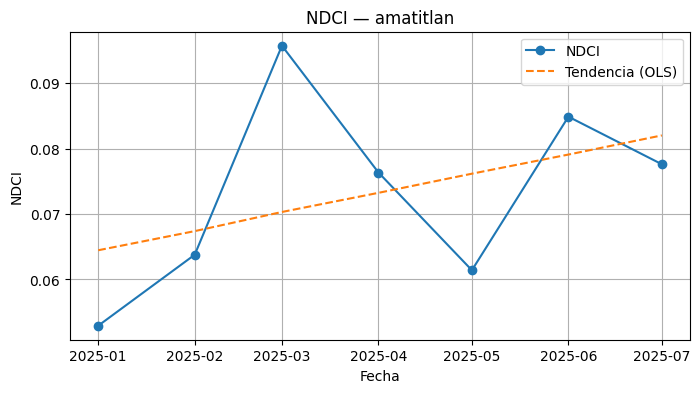

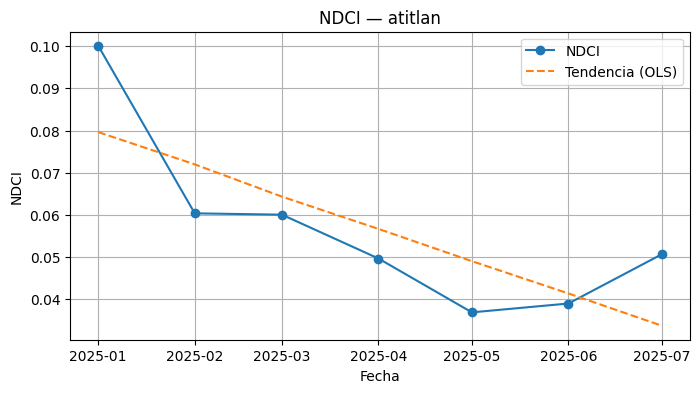

In [47]:

def month_index(dates: pd.Series) -> pd.Series:
    m = dates.dt.year * 12 + dates.dt.month
    return m - m.min()

for lake in df_all["lake"].unique():
    sub = df_all[df_all["lake"] == lake].sort_values("date")
    t = month_index(sub["date"]).astype(float).values
    y = sub["ndci_mean"].values
    lr = linregress(t, y)
    yhat = lr.intercept + lr.slope * t

    plt.figure(figsize=(8,4))
    plt.plot(sub["date"], y, marker="o", label="NDCI")
    plt.plot(sub["date"], yhat, linestyle="--", label="Tendencia (OLS)")
    plt.title(f"NDCI — {lake}")
    plt.xlabel("Fecha"); plt.ylabel("NDCI")
    plt.legend(); plt.grid(True)
    plt.show()


En Amatitlan el NDCI muestra una pendiente OLS positiva (+0.00385 por mes ≈ +0.046/año; p = 0.35) y el test de Mann–Kendall no detecta tendencia (p ≈ 0.37). NDVI también sube (≈ +0.176/año; p = 0.14) y NDWI baja (≈ −0.130/año; p = 0.22). Hay indicios de aumento de biomasa fotosintética y disminución de agua libre, pero estadísticamente no alcanza significancia con esta longitud de serie.

En Atitlan el NDCI tiene pendiente OLS negativa (−0.00653 por mes ≈ −0.078/año) y resulta significativa (p = 0.036). El Mann–Kendall salio con menos potencia para n=7, no la confirma (p ≈ 0.13), pero la dirección coincide con descenso de NDCI en el periodo. NDVI tambien tiende a bajar y NDWI a subir, lo que es coherente con menor presencia de cianobacterias y más agua libre hacia mayo, como ya se vio en los mapas mínimo/máximo.

- Amatitlán: señales de incremento de cianobacterias en el semestre, no significativas aún.

- Atitlán: disminución de cianobacterias en el semestre, significativa por OLS y consistente con NDVI/NDWI, aunque MK no la confirma

Las diferencias observadas entre Amatitla y Atitla son coherentes con contextos fisicos ambientales contrastantes, Amatitlan tiene mayor presion urbana y agroindustrial en su cuenca, recibe cargas de nutrientes y sedimentos más constantes, eso favorece la estratificacion, el calentamiento superficial y la disponibilidad de fósforo/nitrógeno que impulsan el fitoplancton (NDVI) y reducen el agua libre, amplificando la probabilidad de proliferación cuando sube la temperatura del agua y arrancan las primeras lluvias que arrastran nutrientes.

Atitlán, al ser más profundo y con mayor volumen/tiempo de residencia, es mas sensible a la mezcla estacional y a la dilución, el incremento de NDWI y la caída de NDVI/NDCI sugieren mas columna de agua limpia y menor biomasa superficial tras periodos de mezcla o aportes relativamente menos eutróficos, tambien la mayor profundidad y el viento pueden aumentar la resuspensión y romper acumulaciones superficiales de cianobacterias.

Factores climáticos como la transición seca-lluviosa, episodios cálidos, uso/ocupación del suelo como la densidad urbana, descargas de aguas residuales, agricultura periurbana y geomorfología como la profundidad, área de cuenca, someridad de orillas explican así por que Amatitlan es mas propenso a picos y Atitlan muestra un descenso en el semestre analizado.

In [48]:
import pandas as pd

dates_with_low_cloud_cover = [
    "2025-02-07", "2025-02-10", "2025-02-25", "2025-02-27", "2025-03-02",
    "2025-03-04", "2025-03-07", "2025-03-09", "2025-03-12", "2025-03-14",
    "2025-03-19", "2025-03-22", "2025-03-24", "2025-03-26", "2025-04-03",
    "2025-04-11", "2025-04-13", "2025-04-15", "2025-04-16", "2025-04-18",
    "2025-04-28", "2025-05-03", "2025-05-13", "2025-05-28", "2025-07-10",
    "2025-07-17", "2025-07-20", "2025-07-24", "2025-08-01"
]

df_dates = pd.DataFrame(dates_with_low_cloud_cover, columns=["date"])

df_dates["date"] = pd.to_datetime(df_dates["date"])

start_date = df_dates["date"].min()
end_date = start_date + pd.Timedelta(days=179)

date_range_180_days = pd.date_range(start=start_date, end=end_date, freq='D')

filtered_dates_df = df_dates[df_dates["date"].isin(date_range_180_days)]

filtered_dates_df.to_csv("180_day_low_cloud_dates.csv", index=False)

print("CSV file '180_day_low_cloud_dates.csv' created successfully.")

CSV file '180_day_low_cloud_dates.csv' created successfully.


In [49]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Atitlán
atitlan_df = df_all[df_all["lake"] == "atitlan"].sort_values("date").copy()

atitlan_df.set_index("date", inplace=True)

ndci_ts = atitlan_df["ndci_mean"]

# ARIMA model
arima_order = (1, 0, 0)
warnings.filterwarnings("ignore")

try:
    model = ARIMA(ndci_ts, order=arima_order)
    model_fit = model.fit()
    print(model_fit.summary())
except Exception as e:
    print(f"Could not fit ARIMA model: {e}")
    print("Consider trying different ARIMA orders or a different time series model due to limited data.")

                               SARIMAX Results                                
Dep. Variable:              ndci_mean   No. Observations:                    7
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  18.343
Date:                Sat, 16 Aug 2025   AIC                            -30.685
Time:                        01:03:20   BIC                            -30.847
Sample:                    01-01-2025   HQIC                           -32.691
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0628      0.020      3.094      0.002       0.023       0.103
ar.L1          0.6297      0.402      1.567      0.117      -0.158       1.417
sigma2         0.0003      0.000      1.054      0.2

In [50]:
n_forecast = 3
try:
    forecast = model_fit.forecast(steps=n_forecast)
    print("Forecasted NDCI values for the next", n_forecast, "months:")
    print(forecast)
except Exception as e:
    print(f"Could not generate forecast: {e}")

Forecasted NDCI values for the next 3 months:
2025-08-01    0.055154
2025-09-01    0.057980
2025-10-01    0.059760
Freq: MS, Name: predicted_mean, dtype: float64


In [54]:
import rasterio
import numpy as np
import pandas as pd
from glob import glob
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import re
import random

# Define the directory containing the monthly TIFF files
IN_DIR = Path("data_tif") # Assuming NDCI tifs are in this directory

# Threshold for classifying cyanobacteria presence (example threshold, may need adjustment)
# Values above this threshold will be considered as having cyanobacteria
NDCI_THRESHOLD = 0.07

# Number of valid pixels to sample per TIFF file
SAMPLE_PER_TIF = 100000 # Adjust based on available memory and desired dataset size

# List to store data for the classification model
classification_data = []

# Process each monthly TIFF file
for tif_path in sorted(glob(str(IN_DIR / "*.tif"))):
    name = Path(tif_path).stem
    m = re.match(r"^(?P<lake>[a-z]+)_(?P<ym>\d{4}-\d{2})$", name)
    if not m:
        print(f"Skipping unexpected file name: {name}")
        continue

    lake = m.group("lake")
    ym = m.group("ym")

    with rasterio.open(tif_path) as ds:
        try:
            # Read bands 1 (B04) and 2 (B05) as masked arrays
            b04 = ds.read(1, masked=True).astype("float64")
            b05 = ds.read(2, masked=True).astype("float64")

            # Calculate NDCI
            with np.errstate(divide="ignore", invalid="ignore"):
                ndci = (b05 - b04) / (b05 + b04)

            # Convert masked array to ndarray with NaNs
            ndci_arr = np.ma.masked_invalid(ndci).filled(np.nan)

            # Create a mask for valid NDCI values (not NaN)
            valid_mask = ~np.isnan(ndci_arr)
            valid_count = np.sum(valid_mask)
            print(f"Processing {name}: Number of valid pixels: {valid_count}")

            if valid_count == 0:
                print(f"No valid pixels found in {name}. Skipping.")
                continue

            # Apply the NDCI threshold to create labels (1 for presence, 0 for absence)
            labels = np.where(ndci_arr > NDCI_THRESHOLD, 1, 0)

            # Get the geographic coordinates (longitude, latitude) for each pixel center
            cols, rows = np.meshgrid(np.arange(ds.width), np.arange(ds.height))
            xs, ys = rasterio.transform.xy(ds.transform, rows, cols)
            lons = np.array(xs)
            lats = np.array(ys)

            # Flatten the arrays BEFORE applying the mask
            lons_flat = lons.flatten()
            lats_flat = lats.flatten()
            ndci_flat = ndci_arr.flatten()
            labels_flat = labels.flatten()

            # Apply the valid mask to the flattened arrays
            valid_lons = lons_flat[valid_mask.flatten()]
            valid_lats = lats_flat[valid_mask.flatten()]
            valid_ndci = ndci_flat[valid_mask.flatten()]
            valid_labels = labels_flat[valid_mask.flatten()]

            # --- Sampling within the loop ---
            # Create a list of indices for the valid data points
            valid_indices = list(range(len(valid_ndci)))

            # Determine the number of samples to take
            num_samples = min(SAMPLE_PER_TIF, len(valid_indices))

            # Randomly sample indices
            sampled_indices = random.sample(valid_indices, num_samples)

            print(f"  Sampling {num_samples} pixels from {valid_count} valid pixels.")

            # Append sampled data to the list
            for i in sampled_indices:
                 classification_data.append({
                     "lake": lake,
                     "date": f"{ym}-01",
                     "lon": valid_lons[i],
                     "lat": valid_lats[i],
                     "ndci": valid_ndci[i],
                     "cyanobacteria_presence": valid_labels[i]
                 })
            print(f"Appended {num_samples} sampled rows for {name}. Total rows collected so far: {len(classification_data)}")


        except Exception as e:
            print(f"Error processing {tif_path}: {e}")


# Create a DataFrame from the collected data
print(f"\nFinished processing all files. Total data points collected: {len(classification_data)}")
if len(classification_data) == 0:
    print("No data collected for classification. Cannot proceed with model training.")
else:
    df_classification = pd.DataFrame(classification_data)
    print(f"DataFrame created with {len(df_classification)} rows.")

    # --- Model Training ---

    # Select features (using NDCI, longitude, and latitude for this example)
    features = ["lon", "lat", "ndci"]
    X = df_classification[features]
    y = df_classification["cyanobacteria_presence"]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train a RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # --- Model Evaluation ---
    y_pred = model.predict(X_test)

    print("Spatial Classification Model Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    print("\nDataFrame with spatial classification data created: df_classification")

Processing amatitlan_2025-01: Number of valid pixels: 1246344
  Sampling 100000 pixels from 1246344 valid pixels.


Appended 100000 sampled rows for amatitlan_2025-01. Total rows collected so far: 100000
Processing amatitlan_2025-02: Number of valid pixels: 1194038
  Sampling 100000 pixels from 1194038 valid pixels.


Appended 100000 sampled rows for amatitlan_2025-02. Total rows collected so far: 200000
Processing amatitlan_2025-03: Number of valid pixels: 1239110
  Sampling 100000 pixels from 1239110 valid pixels.


Appended 100000 sampled rows for amatitlan_2025-03. Total rows collected so far: 300000
Processing amatitlan_2025-04: Number of valid pixels: 1022941
  Sampling 100000 pixels from 1022941 valid pixels.
Appended 100000 sampled rows for amatitlan_2025-04. Total rows collected so far: 400000


Processing amatitlan_2025-05: Number of valid pixels: 1246896
  Sampling 100000 pixels from 1246896 valid pixels.


...

Appended 100000 sampled rows for atitlan_2025-02. Total rows collected so far: 900000
Processing atitlan_2025-03: Number of valid pixels: 3473601
  Sampling 100000 pixels from 3473601 valid pixels.


Appended 100000 sampled rows for atitlan_2025-03. Total rows collected so far: 1000000
Processing atitlan_2025-04: Number of valid pixels: 3826760
  Sampling 100000 pixels from 3826760 valid pixels.


Appended 100000 sampled rows for atitlan_2025-04. Total rows collected so far: 1100000
Processing atitlan_2025-05: Number of valid pixels: 4720869
  Sampling 100000 pixels from 4720869 valid pixels.


Appended 100000 sampled rows for atitlan_2025-05. Total rows collected so far: 1200000
Processing atitlan_2025-06: Number of valid pixels: 4831009
  Sampling 100000 pixels from 4831009 valid pixels.


Appended 100000 sampled rows for atitlan_2025-06. Total rows collected so far: 1300000
Processing atitlan_2025-07: Number of valid pixels: 4823165
  Sampling 100000 pixels from 4823165 valid pixels.
Appended 100000 sampled rows for atitlan_2025-07. Total rows collected so far: 1400000

Finished processing all files. Total data points collected: 1400000
DataFrame created with 1400000 rows.
Spatial Classification Model Performance:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    292804
           1       1.00      1.00      1.00    127196

    accuracy                           1.00    420000
   macro avg       1.00      1.00      1.00    420000
weighted avg       1.00      1.00      1.00    420000


DataFrame with spatial classification data created: df_classification


In [72]:
# Step 4: Hybrid Model (Combining time series and spatial data)
# modelo hubrido
df_classification['lake'] = df_classification['lake'].str.lower().str.strip()
df_all['lake'] = df_all['lake'].str.lower().str.strip()


df_classification['date_dt'] = pd.to_datetime(df_classification['date'])
df_all['date_dt'] = pd.to_datetime(df_all['date'])

mean_ndci_lookup = df_all.set_index(['date_dt', 'lake'])['ndci_mean']

df_classification['predicted_ndci'] = df_classification.set_index(['date_dt', 'lake']).index.map(mean_ndci_lookup)

df_hybrid_data = df_classification.drop(columns=['date_dt']).copy()


print("\nSample of 'predicted_ndci' column after mapping:")
print(df_hybrid_data['predicted_ndci'].head())
print("\nNumber of non-NaN values in 'predicted_ndci' after mapping:", df_hybrid_data['predicted_ndci'].notna().sum())
print("\nTotal rows in df_hybrid_data after mapping:", len(df_hybrid_data))

hybrid_features = ["lon", "lat", "ndci", "predicted_ndci"]

df_hybrid = df_hybrid_data.dropna(subset=['predicted_ndci']).copy()

if len(df_hybrid) == 0:
    print("No data available for hybrid model training after merging and filtering.")
else:
    X_hybrid = df_hybrid[hybrid_features]
    y_hybrid = df_hybrid["cyanobacteria_presence"]

    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
        X_hybrid, y_hybrid, test_size=0.3, random_state=42
    )

    hybrid_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    hybrid_model.fit(X_train_hybrid, y_train_hybrid)

    print("Hybrid Model trained successfully.")

    # Step 5: Model Prediction and Analysis

    if 'model' in locals():

        spatial_features_for_comparison = ["lon", "lat", "ndci"]
        X_test_spatial_comparison = X_test_hybrid[spatial_features_for_comparison]

        y_pred_spatial = model.predict(X_test_spatial_comparison)
        print("\nSpatial Model Predictions Performance (on hybrid test data subset):")
        print("Accuracy:", accuracy_score(y_test_hybrid, y_pred_spatial))
        print(classification_report(y_test_hybrid, y_pred_spatial))
    else:
         print("\nSpatial model ('model' variable) not found. Please run Step 3 code first.")


    # Predictions with the Hybrid Model
    y_pred_hybrid = hybrid_model.predict(X_test_hybrid)

    print("\nHybrid Model Predictions Performance:")
    print("Accuracy:", accuracy_score(y_test_hybrid, y_pred_hybrid))
    print(classification_report(y_test_hybrid, y_pred_hybrid))


Sample of 'predicted_ndci' column after mapping:
0    0.052929
1    0.052929
2    0.052929
3    0.052929
4    0.052929
Name: predicted_ndci, dtype: float64

Number of non-NaN values in 'predicted_ndci' after mapping: 1400000

Total rows in df_hybrid_data after mapping: 1400000
Hybrid Model trained successfully.

Spatial Model Predictions Performance (on hybrid test data subset):
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    292804
           1       1.00      1.00      1.00    127196

    accuracy                           1.00    420000
   macro avg       1.00      1.00      1.00    420000
weighted avg       1.00      1.00      1.00    420000


Hybrid Model Predictions Performance:
Accuracy: 0.9999976190476191
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    292804
           1       1.00      1.00      1.00    127196

    accuracy                           1.00 

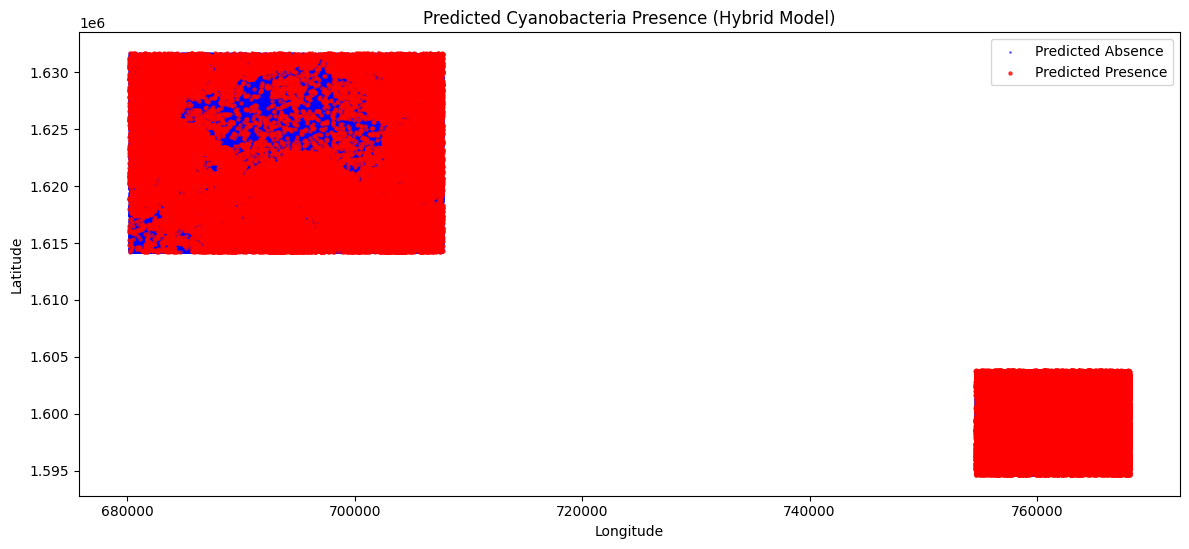

In [71]:
# Step 6: Visualize Results

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

if 'X_test_hybrid' in locals() and 'y_pred_hybrid' in locals():

    # GeoDataFrame
    geometry = [Point(xy) for xy in zip(X_test_hybrid["lon"], X_test_hybrid["lat"])]
    gdf_predictions = gpd.GeoDataFrame(X_test_hybrid, geometry=geometry)
    gdf_predictions['predicted_presence'] = y_pred_hybrid

    gdf_predictions.crs = "EPSG:32615"

    gdf_presence = gdf_predictions[gdf_predictions['predicted_presence'] == 1]
    gdf_absence = gdf_predictions[gdf_predictions['predicted_presence'] == 0]

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    gdf_absence.plot(ax=ax, marker='o', color='blue', markersize=1, label='Predicted Absence', alpha=0.5)

    gdf_presence.plot(ax=ax, marker='o', color='red', markersize=5, label='Predicted Presence', alpha=0.7)

    ax.set_title('Predicted Cyanobacteria Presence (Hybrid Model)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.legend()

    plt.tight_layout()

    plt.show()

else:
    print("Hybrid model test data (X_test_hybrid, y_pred_hybrid) not found. Please run steps 4 and 5 code first.")

Dado que estos resultados provienen de modelos entrenados y evaluados con datos que incluyen al Lago Atitlán, podemos inferir que, para el período analizado y utilizando el umbral de NDCI de 0.07 para definir la presencia de cianobacterias, existe una relación muy fuerte y clara entre las características espaciales (longitud y latitud), el valor de NDCI en un punto dado, y el promedio mensual histórico de NDCI, con la presencia o ausencia de cianobacterias. Los modelos han aprendido a diferenciar estas condiciones con una altísima fiabilidad dentro del conjunto de datos de prueba.